# ASD Detection from Clinical Screening Data

Machine learning pipeline for early-stage autism spectrum disorder (ASD) screening from AQ-10 questionnaire data. The notebook reproduces and extends the workflow of the MSc thesis *Early-stage ASD Detection from Clinical Test Data* (Jahangirnagar University, 2024).

**Dataset:** Kaggle *Autism Prediction in Adults* (REVA Academy), `train.csv`.

## Method

- Preprocessing (imputation, scaling, one-hot encoding) runs inside scikit-learn pipelines and is fitted on training folds only.
- Ten classifiers are compared: AdaBoost, decision tree, random forest, Naive Bayes, LDA, KNN, Fuzzy C-Means, K-Means, MLR with logistic regression, and an SVM on the MLR score and age. A supplementary SVM on age and result is also reported.
- Decision tree size is selected with the one standard error rule inside each training fold.
- Model probabilities are Platt-calibrated and combined by entropy-weighted fusion, with an equal-weight soft vote as a control.
- Models are evaluated at the default threshold and at a matched recall, since accuracy is a poor summary at about 20% prevalence.
- Results are the mean and standard deviation over repeated stratified cross-validation, with the AQ-10 scoring rule and a majority-class rule as baselines.

## Requirements

Python 3.9+, `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn>=1.2`. `ucimlrepo` is only needed for the optional fallback dataset.

## Usage

Place `train.csv` next to the notebook (or upload it when prompted in Colab) and run all cells. Settings are defined in the configuration block of section 1.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_predict, cross_val_score, train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
CSV_PATH = "train.csv"
USE_RESULT = True               # hold-out run only; section 9 reports both settings
N_SPLITS, N_REPEATS = 5, 2
TARGET_RECALL = 0.90
PARAMS = dict(knn_k=11, rf_trees=200, ada_trees=150, svm_C=1.0)
OP_DEF = "default (p>=0.5)"
OP_REC = f"matched recall>={TARGET_RECALL:.2f}"

AQ_COLUMNS = [f"A{i}_Score" for i in range(1, 11)]
BINARY_COLS = ["gender", "jaundice", "austim"]
CAT_COLS = ["relation"]
ALIASES = {"jaundice": {"jaundice", "jundice"}, "austim": {"austim", "family_pdd", "pdd"}}
TARGET_NAMES = {"class/asd", "class", "asd", "target", "class_asd"}
YESNO = {"yes": 1, "no": 0, "y": 1, "n": 0, "true": 1, "false": 0,
         "1": 1, "0": 0, "1.0": 1, "0.0": 0}
GENDER = {"m": 1, "male": 1, "f": 0, "female": 0}

## 2. Data loading

The notebook uses the Kaggle *Autism Prediction* dataset (`train.csv`, 800 rows), available from the [competition page](https://www.kaggle.com/competitions/autismdiagnosis). The file is not included in this repository.

It is looked up in the working directory, `./data/`, `/content/` (Colab) and `/kaggle/input/`. In Colab, if it is not found, you are prompted to upload it.

In [2]:
KAGGLE_URL = "https://www.kaggle.com/competitions/autismdiagnosis"
REQUIRED_COLUMNS = AQ_COLUMNS + ["age", "gender", "jaundice", "austim", "relation", "result", "Class/ASD"]


def find_csv():
    """Look for train.csv in the usual places (working directory, ./data, Colab, Kaggle notebooks)."""
    candidates = [Path(CSV_PATH), Path("data") / "train.csv", Path("/content/train.csv")]
    candidates += sorted(Path("/kaggle/input").glob("**/train.csv"))
    return next((p for p in candidates if p.is_file()), None)


def upload_csv():
    """Ask for the file through the Colab upload dialog."""
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("No file uploaded. Re-run this cell and choose train.csv.")
    return Path(next(iter(uploaded)))


def load_data():
    """Load the Kaggle 'Autism Prediction' train.csv and verify that it has the expected columns."""
    path = find_csv()
    if path is None:
        try:
            import google.colab  # noqa: F401
        except ImportError:
            raise FileNotFoundError(
                f"train.csv not found. Download it from {KAGGLE_URL} and place it next to this notebook "
                f"(or in ./data/), or set CSV_PATH in the setup cell."
            ) from None
        path = upload_csv()

    df = pd.read_csv(path, na_values=["?", ""])
    df.columns = [str(c).strip() for c in df.columns]

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(
            f"{path} does not look like the Kaggle train.csv (missing columns: {missing}). "
            f"The UCI version of the dataset and Kaggle's test.csv are not supported."
        )
    if len(df) != 800:
        print(f"Warning: expected 800 rows in the Kaggle train.csv, found {len(df)}.")

    print("Loaded:", path)
    return df


raw = load_data()
print(raw.shape)
raw.head()

Saving train.csv to train.csv
Loaded uploaded file: train.csv
(800, 22)


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,NaN,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,NaN,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,NaN,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,NaN,no,no,South Africa,no,-4.777286,18 and more,Self,0


## 3. Data cleaning

Only deterministic, row-wise mappings are applied here. Anything fitted from data lives inside the model pipelines. The final block summarises how informative `result` is.

In [3]:
def clean(df):
    """Standardise column names, encode binary fields and return (features, label)."""
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    rename = {c: canon for c in df.columns for canon, names in ALIASES.items() if c.lower() in names}
    df = df.rename(columns=rename)

    target = ([c for c in df.columns if c.lower() in TARGET_NAMES]
              or [c for c in df.columns if "class" in c.lower()])
    if not target:
        raise KeyError(f"Could not find the label column. Columns: {list(df.columns)}")
    y = df[target[0]].astype(str).str.strip().str.lower().map(YESNO)

    keep = [c for c in AQ_COLUMNS + ["age", "gender", "jaundice", "austim", "relation", "result"]
            if c in df.columns]
    X = df[keep].copy()
    for c in AQ_COLUMNS + ["age", "result"]:
        if c in X:
            X[c] = pd.to_numeric(X[c], errors="coerce")
    X.loc[(X["age"] < 1) | (X["age"] > 120), "age"] = np.nan   # imputed inside the pipelines
    X["gender"] = X["gender"].astype(str).str.strip().str.lower().map(GENDER)
    for c in ["jaundice", "austim"]:
        X[c] = X[c].astype(str).str.strip().str.lower().map(YESNO)
    if "relation" in X:
        known = X["relation"].notna()
        X["relation"] = X["relation"].astype("object").where(known, "Unknown").astype(str).str.strip()

    valid = y.notna()
    return X[valid].reset_index(drop=True), y[valid].astype(int).reset_index(drop=True)


X, y = clean(raw)
print("X:", X.shape, "| positives:", f"{y.mean():.1%}",
      "| majority-class accuracy:", f"{max(y.mean(), 1 - y.mean()):.1%}")
print("missing values per column:\n", X.isna().sum()[X.isna().sum() > 0])

if "result" in X:
    aq_sum = X[AQ_COLUMNS].sum(axis=1)
    r = X["result"]
    ok = r.notna()
    print("\n--- How informative is `result`? ---")
    print(f"corr(result, AQ sum)              : {np.corrcoef(r[ok], aq_sum[ok])[0, 1]:.3f}")
    print(f"share of rows with result == sum  : {(r == aq_sum).mean():.1%}")
    print(f"rows with result < 0 (impossible for an AQ-10 sum): {(r < 0).mean():.1%}")
    print(f"ROC-AUC of `result` alone vs label: {roc_auc_score(y[ok], r[ok]):.3f}")
    print(f"ROC-AUC of AQ sum alone vs label  : {roc_auc_score(y, aq_sum):.3f}")

X: (800, 16) | positives: 20.1% | majority-class accuracy: 79.9%
missing values per column:
 Series([], dtype: int64)

--- How informative is `result`? ---
corr(result, AQ sum)              : 0.515
share of rows with result == sum  : 0.0%
rows with result < 0 (impossible for an AQ-10 sum): 6.1%
ROC-AUC of `result` alone vs label: 0.770
ROC-AUC of AQ sum alone vs label  : 0.910


## 4. Exploratory data analysis

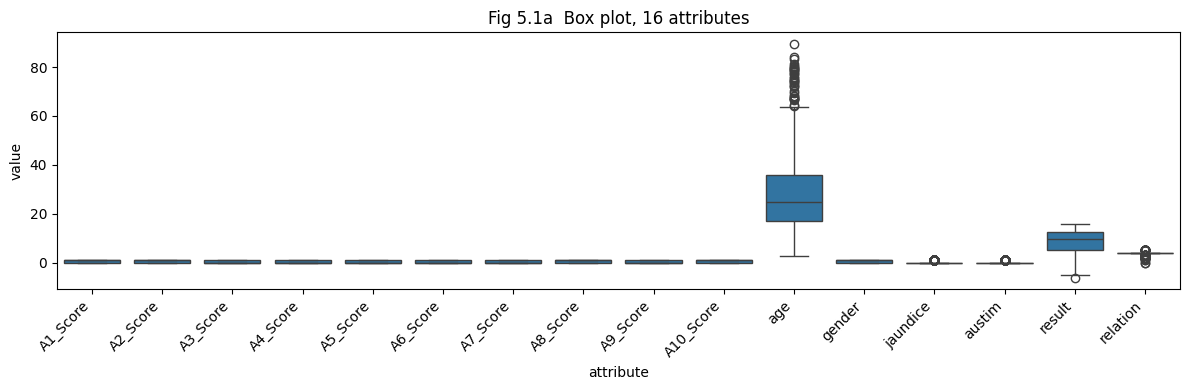

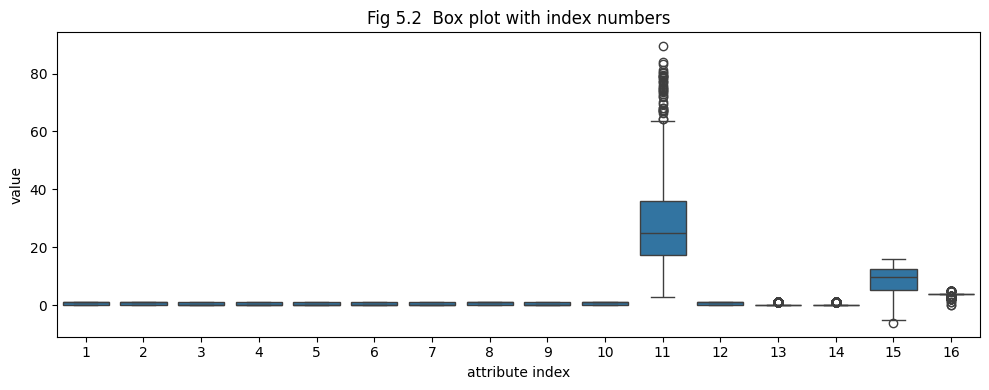

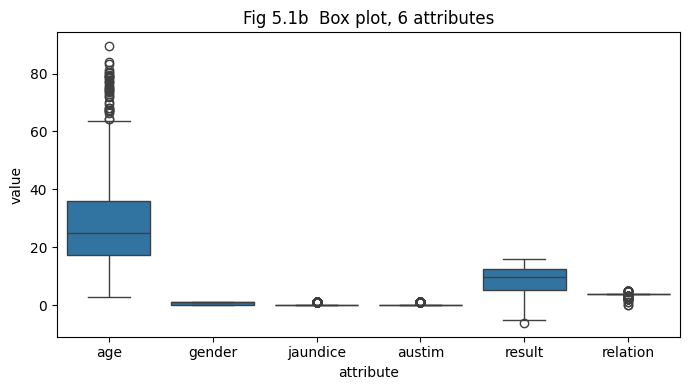

In [4]:
eda = X.copy()
if "relation" in eda:
    eda["relation"] = eda["relation"].astype("category").cat.codes
eda["Class_ASD"] = y.map({0: "no", 1: "yes"})
key_attrs = [c for c in ["age", "gender", "jaundice", "austim", "result", "relation"] if c in eda]
all_attrs = [c for c in AQ_COLUMNS + key_attrs if c in eda]
melt_all = eda[all_attrs].melt(var_name="attribute", value_name="value")

plt.figure(figsize=(12, 4))
sns.boxplot(data=melt_all, x="attribute", y="value")
plt.xticks(rotation=45, ha="right")
plt.title(f"Fig 5.1a  Box plot, {len(all_attrs)} attributes")
plt.tight_layout()
plt.show()

attr_index = {name: i + 1 for i, name in enumerate(all_attrs)}
melt_idx = melt_all.assign(idx=melt_all["attribute"].map(attr_index))
plt.figure(figsize=(10, 4))
sns.boxplot(data=melt_idx, x="idx", y="value")
plt.xlabel("attribute index")
plt.title("Fig 5.2  Box plot with index numbers")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=eda[key_attrs].melt(var_name="attribute", value_name="value"), x="attribute", y="value")
plt.title(f"Fig 5.1b  Box plot, {len(key_attrs)} attributes")
plt.tight_layout()
plt.show()

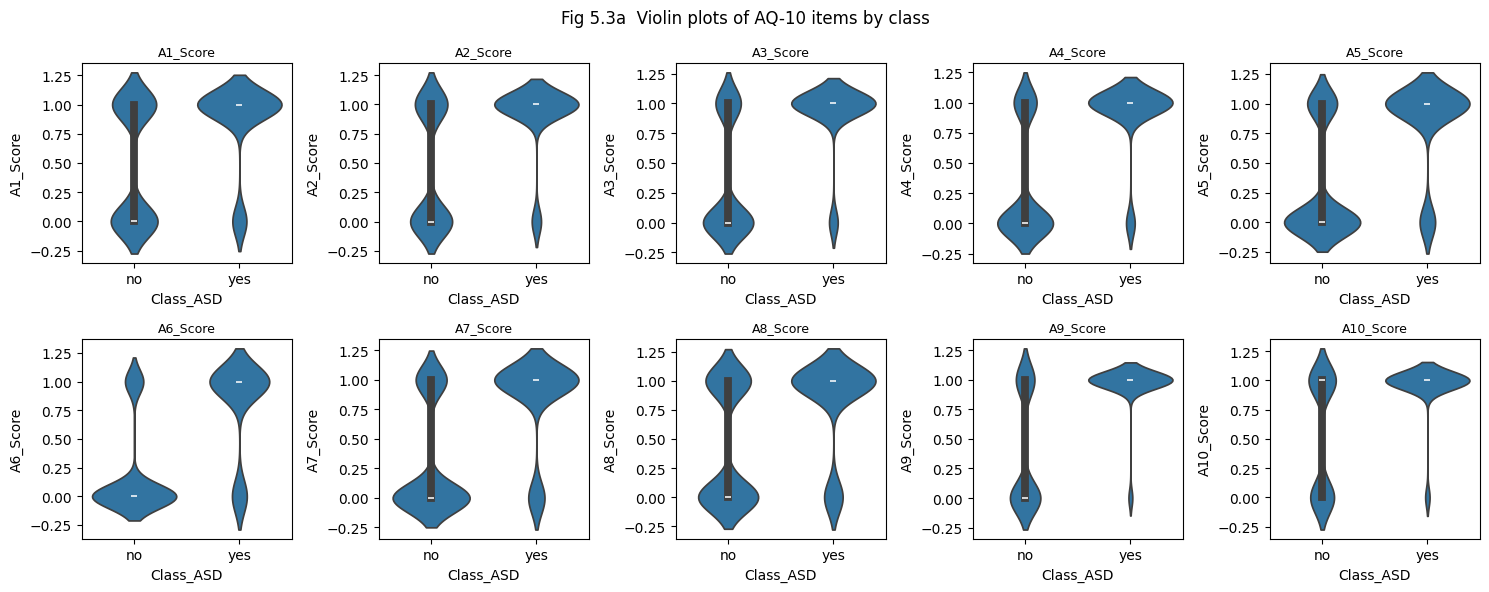

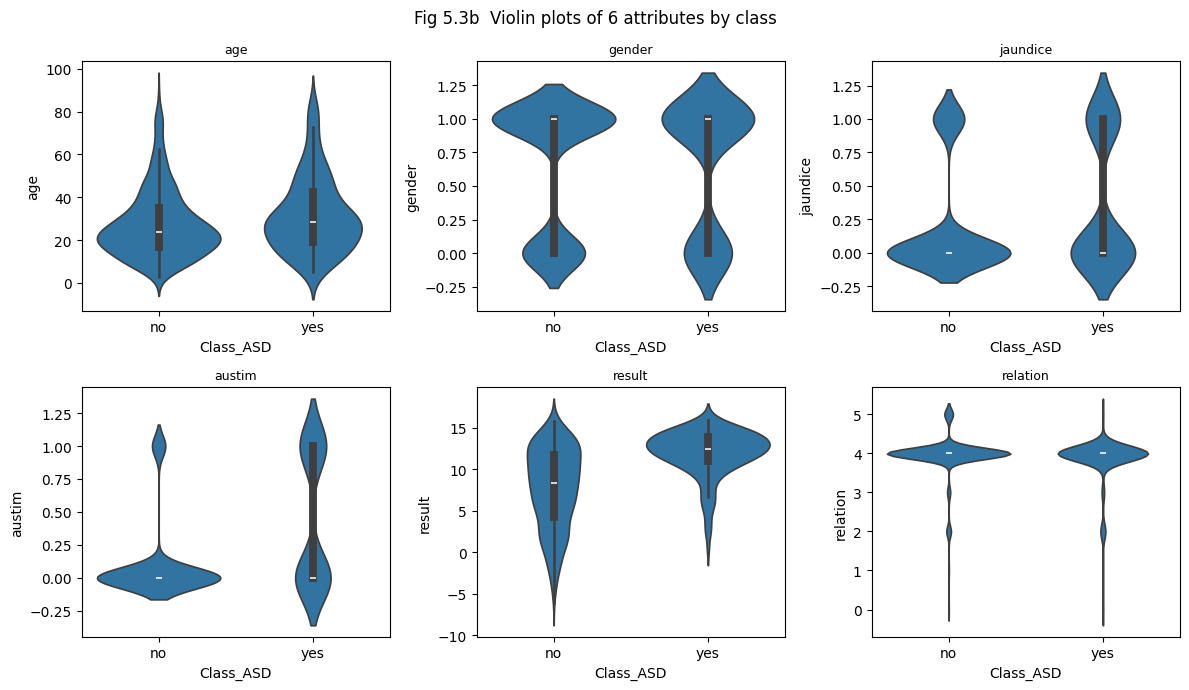

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, col in zip(axes.flat, AQ_COLUMNS):
    sns.violinplot(data=eda, x="Class_ASD", y=col, order=["no", "yes"], ax=ax)
    ax.set_title(col, fontsize=9)
fig.suptitle("Fig 5.3a  Violin plots of AQ-10 items by class")
plt.tight_layout()
plt.show()

ncol = 3
nrow = int(np.ceil(len(key_attrs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3.5 * nrow))
for ax, col in zip(axes.flat, key_attrs):
    sns.violinplot(data=eda, x="Class_ASD", y=col, order=["no", "yes"], ax=ax)
    ax.set_title(col, fontsize=9)
for ax in list(axes.flat)[len(key_attrs):]:
    ax.axis("off")
fig.suptitle(f"Fig 5.3b  Violin plots of {len(key_attrs)} attributes by class")
plt.tight_layout()
plt.show()

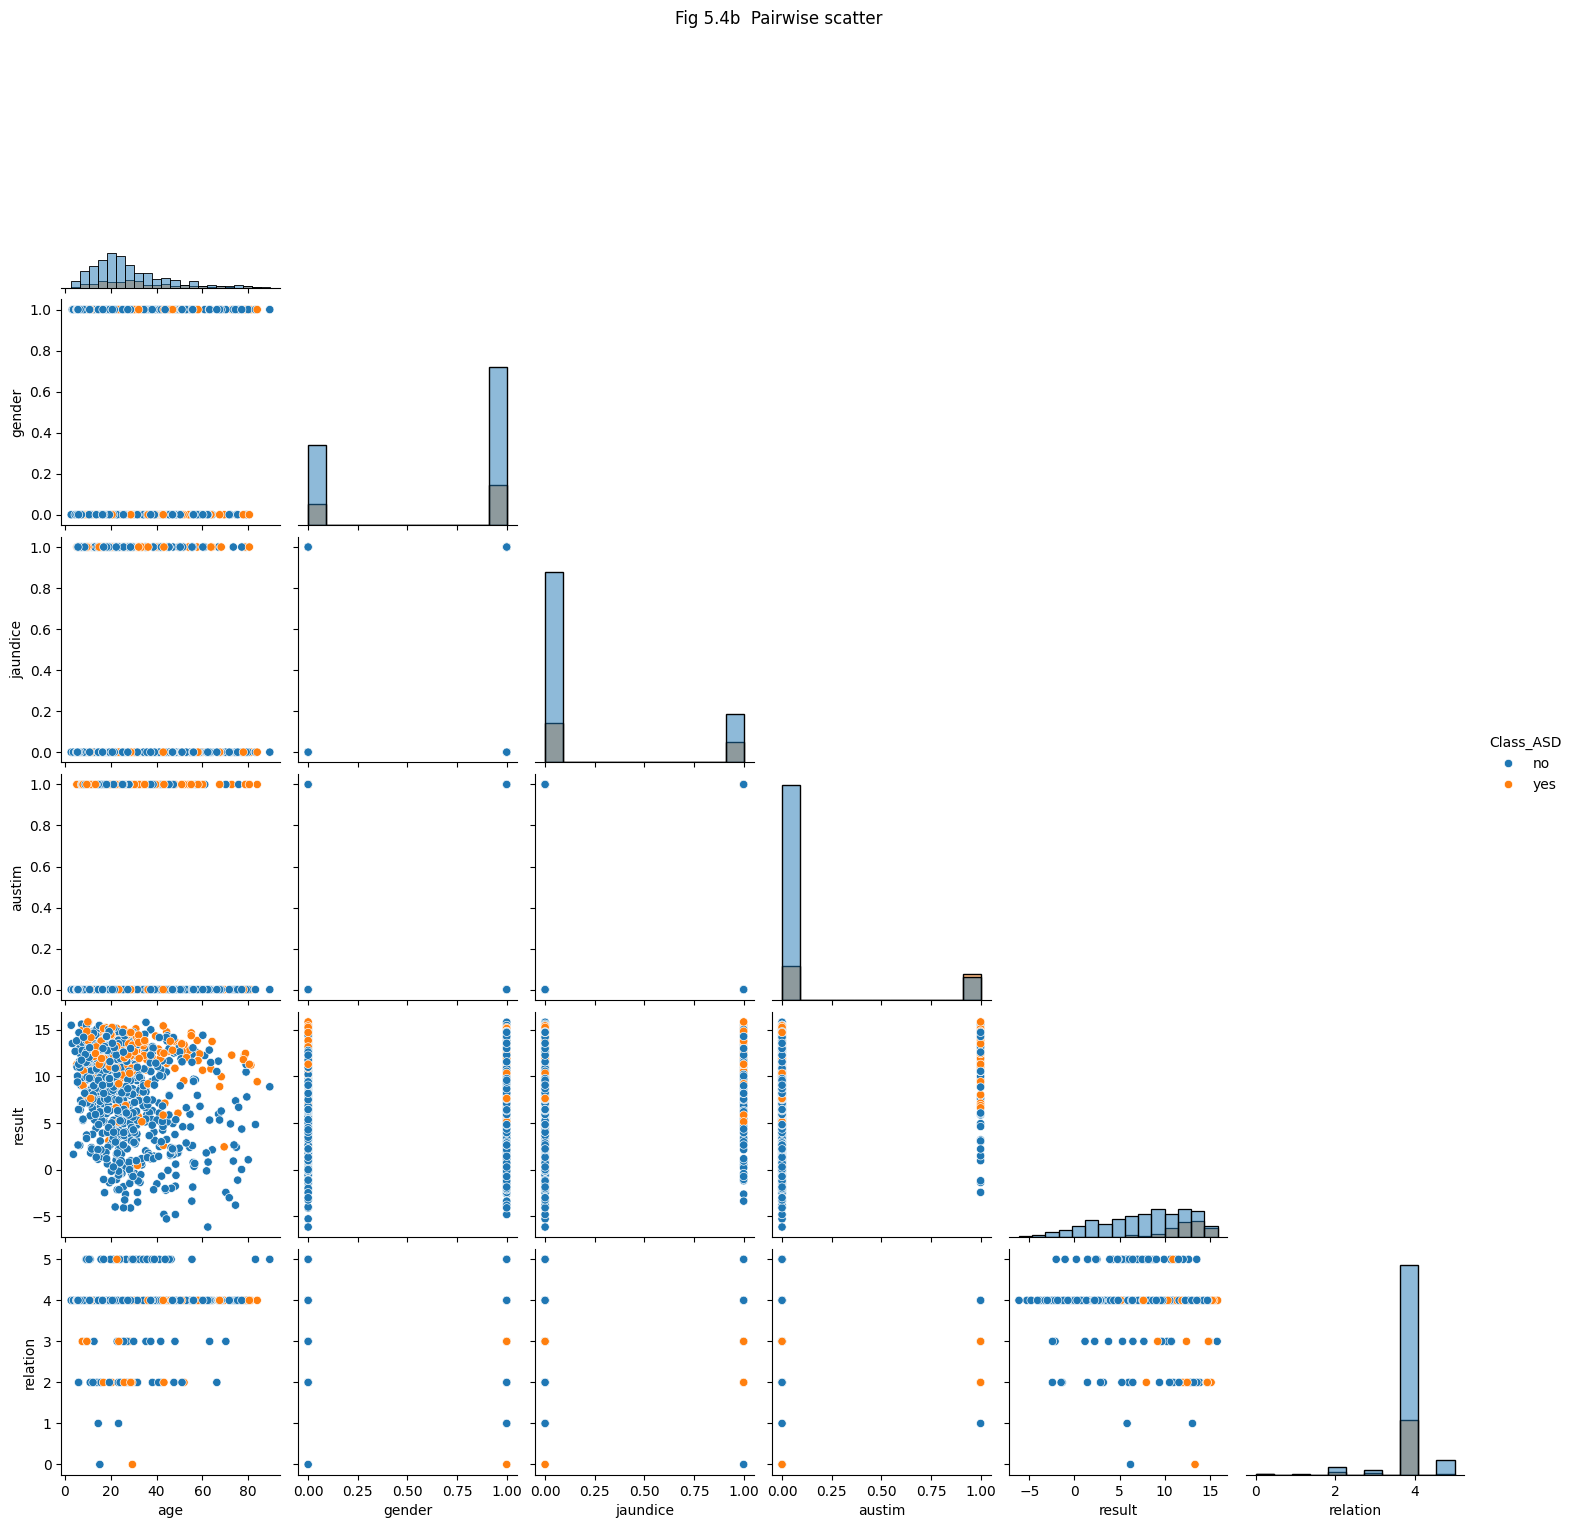

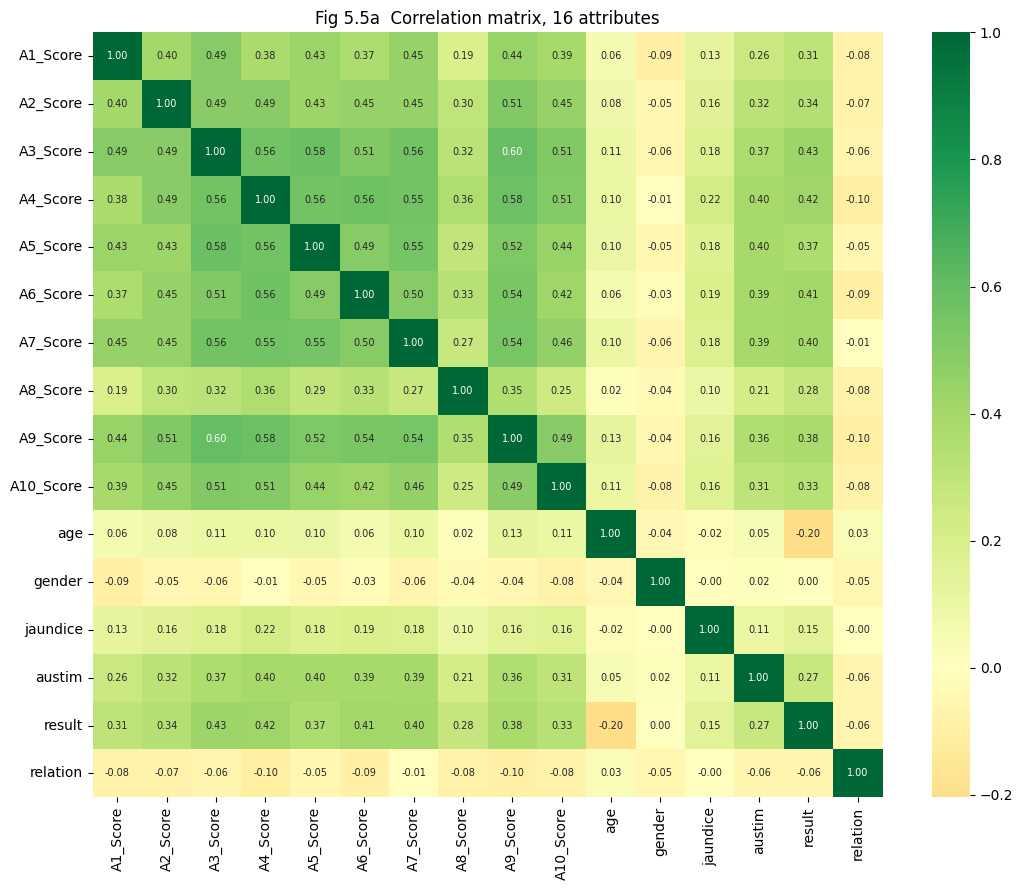

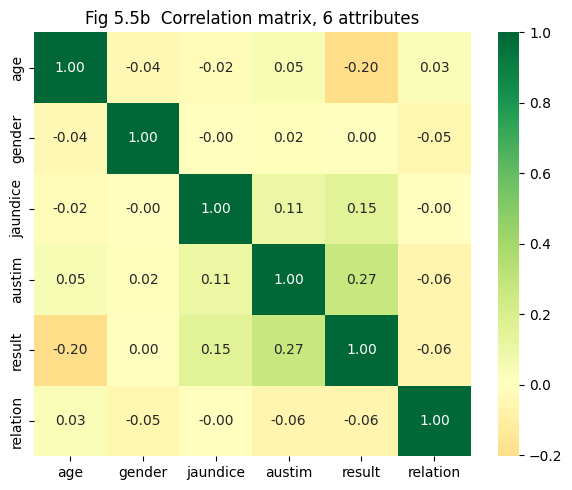

In [6]:
sns.pairplot(eda[key_attrs + ["Class_ASD"]], hue="Class_ASD", corner=True, diag_kind="hist")
plt.suptitle("Fig 5.4b  Pairwise scatter", y=1.02)
plt.show()

plt.figure(figsize=(11, 9))
sns.heatmap(eda[all_attrs].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0, annot_kws={"size": 7})
plt.title(f"Fig 5.5a  Correlation matrix, {len(all_attrs)} attributes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(eda[key_attrs].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title(f"Fig 5.5b  Correlation matrix, {len(key_attrs)} attributes")
plt.tight_layout()
plt.show()

## 5. Model components

- **Preprocessing** (fitted on training data only): median imputation and scaling for `age` and `result`, mode imputation for binary columns, imputation and one-hot encoding for `relation`.
- **Polar recoding** (thesis step iii) maps binary columns to -1/+1 in the MLR branch. It does not change the predictions of a linear regression with intercept and is kept for fidelity with the workflow.
- **MLR** is a multiple linear regression of the label on all features, giving one real-valued score. Logistic regression is applied to that score (step vi), and the SVM to the normalised plane of MLR score and age (step vii).
- **Fuzzy C-Means and K-Means** are unsupervised. Each cluster takes the class with the higher positive rate, so both classes are always predicted.

In [7]:
def to_polar(a):
    return 2.0 * np.asarray(a, dtype=float) - 1.0


def make_prep(cols, use_result, polar=False):
    """Column transformer: scaled numeric, binary (optionally polar), one-hot categorical."""
    num = [c for c in ["age", "result"] if c in cols and (c == "age" or use_result)]  # age must stay first
    binc = [c for c in AQ_COLUMNS + BINARY_COLS if c in cols]
    cat = [c for c in CAT_COLS if c in cols]

    bin_steps = [("imp", SimpleImputer(strategy="most_frequent"))]
    if polar:
        bin_steps.append(("polar", FunctionTransformer(to_polar, feature_names_out="one-to-one")))

    transformers = [
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
        ("bin", Pipeline(bin_steps), binc),
    ]
    if cat:
        transformers.append(("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat))
    return ColumnTransformer(transformers)


class MLRScore(TransformerMixin, BaseEstimator):
    """Linear regression of y on X. Output columns: [score, X[:, keep]...]."""

    def __init__(self, keep=()):
        self.keep = keep

    def fit(self, X, y):
        self.lr_ = LinearRegression().fit(X, y)
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.hstack([self.lr_.predict(X).reshape(-1, 1), X[:, list(self.keep)]])


def _fcm(X, c, m, tol, max_iter, rng):
    """Fuzzy C-Means; returns centers, memberships and the objective value."""
    U = rng.random((c, len(X)))
    U /= U.sum(0)
    for _ in range(max_iter):
        Um = U ** m
        centers = (Um @ X) / Um.sum(1, keepdims=True)
        d = np.linalg.norm(X[None, :, :] - centers[:, None, :], axis=2) + 1e-12
        U_new = 1.0 / np.sum((d[:, None, :] / d[None, :, :]) ** (2.0 / (m - 1.0)), axis=1)
        done = np.abs(U_new - U).max() < tol
        U = U_new
        if done:
            break
    d = np.linalg.norm(X[None, :, :] - centers[:, None, :], axis=2) + 1e-12
    return centers, U, float(((U ** m) * d ** 2).sum())


def _memberships(X, centers, m):
    d = np.linalg.norm(X[None, :, :] - centers[:, None, :], axis=2) + 1e-12
    return 1.0 / np.sum((d[:, None, :] / d[None, :, :]) ** (2.0 / (m - 1.0)), axis=1)


class FuzzyCMeansClassifier(ClassifierMixin, BaseEstimator):
    """Two-cluster Fuzzy C-Means; the cluster with the higher positive rate is class 1."""

    def __init__(self, m=2.0, n_init=5, max_iter=300, tol=1e-5, random_state=0):
        self.m = m
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y)
        rng = np.random.default_rng(self.random_state)
        runs = (_fcm(X, 2, self.m, self.tol, self.max_iter, rng) for _ in range(self.n_init))
        self.centers_, U, _ = min(runs, key=lambda t: t[2])
        labels = U.argmax(0)
        rate = [y[labels == k].mean() if (labels == k).any() else y.mean() for k in range(2)]
        self.pos_cluster_ = int(np.argmax(rate))
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        p1 = _memberships(np.asarray(X, float), self.centers_, self.m)[self.pos_cluster_]
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


class KMeansClassifier(ClassifierMixin, BaseEstimator):
    """Two-cluster K-Means; the cluster with the higher positive rate is class 1."""

    def __init__(self, random_state=0):
        self.random_state = random_state

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y)
        self.km_ = KMeans(2, n_init=10, random_state=self.random_state).fit(X)
        labels = self.km_.labels_
        rate = [y[labels == k].mean() if (labels == k).any() else y.mean() for k in range(2)]
        self.pos_cluster_ = int(np.argmax(rate))
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        d = self.km_.transform(np.asarray(X, float)) + 1e-12
        p1 = d[:, 1 - self.pos_cluster_] / d.sum(1)
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def build_models(cols, use_result, dt_leaves=5):
    """Return the model pipelines keyed by display name."""
    p, rs = PARAMS, RANDOM_STATE

    def prep(polar=False):
        return make_prep(cols, use_result, polar)

    models = {
        "AdaBoost": Pipeline([("prep", prep()),
                              ("clf", AdaBoostClassifier(n_estimators=p["ada_trees"], random_state=rs))]),
        "Decision Tree": Pipeline([("prep", prep()),
                                   ("clf", DecisionTreeClassifier(max_leaf_nodes=dt_leaves, random_state=rs))]),
        "Random Forest": Pipeline([("prep", prep()),
                                   ("clf", RandomForestClassifier(n_estimators=p["rf_trees"], random_state=rs, n_jobs=-1))]),
        "Naive Bayes": Pipeline([("prep", prep()), ("clf", GaussianNB())]),
        "LDA": Pipeline([("prep", prep()), ("clf", LinearDiscriminantAnalysis())]),
        "KNN": Pipeline([("prep", prep()), ("clf", KNeighborsClassifier(n_neighbors=p["knn_k"]))]),
        "Fuzzy C-Means": Pipeline([("prep", prep()), ("clf", FuzzyCMeansClassifier(random_state=rs))]),
        "K-Means": Pipeline([("prep", prep()), ("clf", KMeansClassifier(random_state=rs))]),
        "MLR + Logistic Regression": Pipeline([("prep", prep(polar=True)), ("mlr", MLRScore()),
                                               ("clf", LogisticRegression())]),
        "SVM (MLR score + age)": Pipeline([
            ("prep", prep(polar=True)), ("mlr", MLRScore(keep=(0,))), ("norm", StandardScaler()),
            ("clf", SVC(C=p["svm_C"], kernel="rbf", probability=True, random_state=rs)),
        ]),
    }
    if use_result and "result" in cols:
        select = ColumnTransformer([("n", Pipeline([("imp", SimpleImputer(strategy="median")),
                                                    ("sc", StandardScaler())]), ["age", "result"])])
        models["SVM (age + result)"] = Pipeline([
            ("sel", select), ("clf", SVC(C=p["svm_C"], probability=True, random_state=rs)),
        ])
    return models


SUPPLEMENTARY = {"SVM (age + result)"}   # reported, but excluded from the fusion


def tree_curve(Xtr, ytr, use_result, leaves=range(2, 21), with_resub=False):
    """Cross-validated error by number of leaves and the one standard error choice."""
    cols, rs = list(Xtr.columns), RANDOM_STATE
    cv = StratifiedKFold(5, shuffle=True, random_state=rs)
    leaves = list(leaves)
    cv_mean, cv_se, resub = [], [], []
    for n_leaves in leaves:
        pipe = Pipeline([("prep", make_prep(cols, use_result)),
                         ("clf", DecisionTreeClassifier(max_leaf_nodes=n_leaves, random_state=rs))])
        err = 1 - cross_val_score(pipe, Xtr, ytr, cv=cv, scoring="accuracy")
        cv_mean.append(err.mean())
        cv_se.append(err.std(ddof=1) / np.sqrt(len(err)))
        if with_resub:
            resub.append(1 - pipe.fit(Xtr, ytr).score(Xtr, ytr))
    cv_mean, cv_se = np.array(cv_mean), np.array(cv_se)
    best = int(np.argmin(cv_mean))
    one_se = next(i for i in range(len(leaves)) if cv_mean[i] <= cv_mean[best] + cv_se[best])
    return dict(leaves=leaves, cv_mean=cv_mean, cv_se=cv_se, resub=resub,
                best=best, one_se=one_se, choice=leaves[one_se])

## 6. Metrics, calibration and fusion

- **Operating points.** Models are evaluated at the default threshold (`p >= 0.5`) and at a matched recall: the largest threshold reaching `TARGET_RECALL` on out-of-fold training predictions, applied unchanged to the test fold. The AQ sum baseline is treated the same way.
- **Calibration.** A Platt sigmoid is fitted on out-of-fold training probabilities (3-fold) and applied to the test probabilities.
- **Entropy fusion.** Each calibrated probability `p` is weighted by `1 - H(p)`, where `H` is the binary entropy; the fused probability is the weighted mean across models. An equal-weight soft vote over the same probabilities serves as a control.

In [8]:
COLS = ["accuracy", "bal_acc", "precision", "recall", "spec", "f1", "auc"]


def logit(p, eps=1e-3):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def metrics(name, fold, op, y_true, pred, p=None):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    out = dict(
        model=name, fold=fold, op=op,
        accuracy=accuracy_score(y_true, pred) * 100,
        bal_acc=balanced_accuracy_score(y_true, pred) * 100,
        precision=precision_score(y_true, pred, zero_division=0),
        recall=recall_score(y_true, pred, zero_division=0),
        spec=tn / (tn + fp) if (tn + fp) else np.nan,
        f1=f1_score(y_true, pred, zero_division=0),
    )
    out["auc"] = roc_auc_score(y_true, p) if p is not None and len(np.unique(y_true)) > 1 else np.nan
    return out


def threshold_for_recall(y_true, score, target):
    """Largest threshold t such that recall(score >= t) >= target."""
    pos = np.sort(np.asarray(score)[np.asarray(y_true) == 1])
    k = int(np.floor((1 - target) * len(pos) + 1e-9))
    return pos[k]


def entropy_fusion(P, eps=1e-6):
    """Fuse calibrated probabilities P (n_models, n_samples) with weights 1 - binary entropy."""
    P = np.clip(P, eps, 1 - eps)
    H = -(P * np.log2(P) + (1 - P) * np.log2(1 - P))
    W = np.maximum(1 - H, 1e-6)
    return (W * P).sum(0) / W.sum(0)


FUSIONS = {
    "Fusion: entropy-weighted (calibrated)": entropy_fusion,
    "Fusion: equal-weight soft vote (calibrated)": lambda P: P.mean(0),
}


def evaluate_fold(Xtr, Xte, ytr, yte, use_result, fold=0):
    """Fit all models on one split and score them at both operating points."""
    cols = list(Xtr.columns)
    rows, fitted, thr = [], {}, {}
    preds, preds_r = {}, {}
    cal, cal_oof = {}, {}
    inner = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)
    ytr_v = ytr.values

    def add(name, op, pred, p):
        rows.append(metrics(name, fold, op, yte, pred, p))

    aq_te = Xte[AQ_COLUMNS].sum(axis=1).values.astype(float)
    aq_tr = Xtr[AQ_COLUMNS].sum(axis=1).values.astype(float)
    add("Baseline: AQ-10 >= 6", OP_DEF, (aq_te >= 6).astype(int), aq_te / 10)
    thr["AQ sum"] = threshold_for_recall(ytr_v, aq_tr, TARGET_RECALL)
    add("Baseline: AQ sum (cutoff chosen on train)", OP_REC, (aq_te >= thr["AQ sum"]).astype(int), aq_te / 10)
    dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
    for op in (OP_DEF, OP_REC):
        add("Baseline: majority class", op, dummy.predict(Xte), dummy.predict_proba(Xte)[:, 1])

    leaves = tree_curve(Xtr, ytr, use_result)["choice"]

    for name, pipe in build_models(cols, use_result, leaves).items():
        oof = cross_val_predict(clone(pipe), Xtr, ytr, cv=inner, method="predict_proba")[:, 1]
        pipe.fit(Xtr, ytr)
        p = pipe.predict_proba(Xte)[:, 1]

        platt = LogisticRegression().fit(logit(oof).reshape(-1, 1), ytr_v)
        cal[name] = platt.predict_proba(logit(p).reshape(-1, 1))[:, 1]
        cal_oof[name] = platt.predict_proba(logit(oof).reshape(-1, 1))[:, 1]

        preds[name], fitted[name] = pipe.predict(Xte), pipe
        thr[name] = threshold_for_recall(ytr_v, oof, TARGET_RECALL)
        preds_r[name] = (p >= thr[name]).astype(int)
        add(name, OP_DEF, preds[name], p)
        add(name, OP_REC, preds_r[name], p)

    names = [n for n in cal if n not in SUPPLEMENTARY]
    P_test = np.vstack([cal[n] for n in names])
    P_oof = np.vstack([cal_oof[n] for n in names])
    for label, fuse in FUSIONS.items():
        fused_test, fused_oof = fuse(P_test), fuse(P_oof)
        cal[label] = fused_test
        preds[label] = (fused_test >= 0.5).astype(int)
        thr[label] = threshold_for_recall(ytr_v, fused_oof, TARGET_RECALL)
        preds_r[label] = (fused_test >= thr[label]).astype(int)
        add(label, OP_DEF, preds[label], fused_test)
        add(label, OP_REC, preds_r[label], fused_test)

    return dict(rows=rows, preds=preds, preds_r=preds_r, cal=cal, fitted=fitted, thr=thr, leaves=leaves)


def summarize(rows, op):
    """Mean +/- std per model at one operating point; also returns the raw mean and std tables."""
    d = pd.DataFrame(rows)
    d = d[d["op"] == op]
    g = d.groupby("model")[COLS]
    mean, std = g.mean(), g.std()
    out = mean.round(3).astype(str) + " ± " + std.round(3).astype(str)
    order = mean.sort_values("bal_acc", ascending=False).index
    return out.loc[order], mean, std


def paired(rows, op, metric, base):
    """Per-fold difference to a baseline model (descriptive; CV folds overlap)."""
    d = pd.DataFrame(rows)
    d = d[d["op"] == op].pivot(index="fold", columns="model", values=metric)
    diff = d.sub(d[base], axis=0).drop(columns=[c for c in d.columns if c.startswith("Baseline")])
    out = pd.DataFrame({f"mean Δ{metric}": diff.mean(), "std": diff.std(), "folds better": (diff > 0).sum()})
    return out.round(3).sort_values(f"mean Δ{metric}", ascending=False)

## 7. Hold-out evaluation

A single stratified 80/20 split (160 test samples, about 32 positives), shown for illustration. Section 9 reports the cross-validated results.

USE_RESULT=True | train (640, 16), test (160, 16) | positives in test: 32
Decision tree size chosen by the 1-SE rule: 3 leaves

--- operating point: default (p>=0.5) ---


,accuracy,bal_acc,precision,recall,spec,f1,auc
model,,,,,,,
KNN,83.750,82.812,0.565,0.812,0.844,0.667,0.865
Decision Tree,83.125,82.422,0.553,0.812,0.836,0.658,0.828
Baseline: AQ-10 >= 6,75.000,82.031,0.441,0.938,0.703,0.600,0.897
Naive Bayes,78.125,81.641,0.475,0.875,0.758,0.615,0.892
K-Means,73.125,80.859,0.423,0.938,0.680,0.583,0.864
Fuzzy C-Means,71.875,80.078,0.411,0.938,0.664,0.571,0.865
LDA,83.750,79.297,0.575,0.719,0.867,0.639,0.890
SVM (MLR score + age),82.500,76.172,0.553,0.656,0.867,0.600,0.820
MLR + Logistic Regression,84.375,76.172,0.606,0.625,0.898,0.615,0.890



--- operating point: matched recall>=0.90 ---


,accuracy,bal_acc,precision,recall,spec,f1,auc
model,,,,,,,
Fusion: entropy-weighted (calibrated),79.375,83.594,0.492,0.906,0.766,0.637,0.892
MLR + Logistic Regression,78.125,82.812,0.475,0.906,0.750,0.624,0.890
LDA,78.125,82.812,0.475,0.906,0.750,0.624,0.890
SVM (MLR score + age),81.875,82.812,0.529,0.844,0.812,0.651,0.820
Baseline: AQ sum (cutoff chosen on train),75.000,82.031,0.441,0.938,0.703,0.600,0.897
Naive Bayes,78.750,80.859,0.482,0.844,0.773,0.614,0.892
Fuzzy C-Means,78.125,80.469,0.474,0.844,0.766,0.607,0.865
Fusion: equal-weight soft vote (calibrated),77.500,80.078,0.466,0.844,0.758,0.600,0.888
KNN,77.500,80.078,0.466,0.844,0.758,0.600,0.865


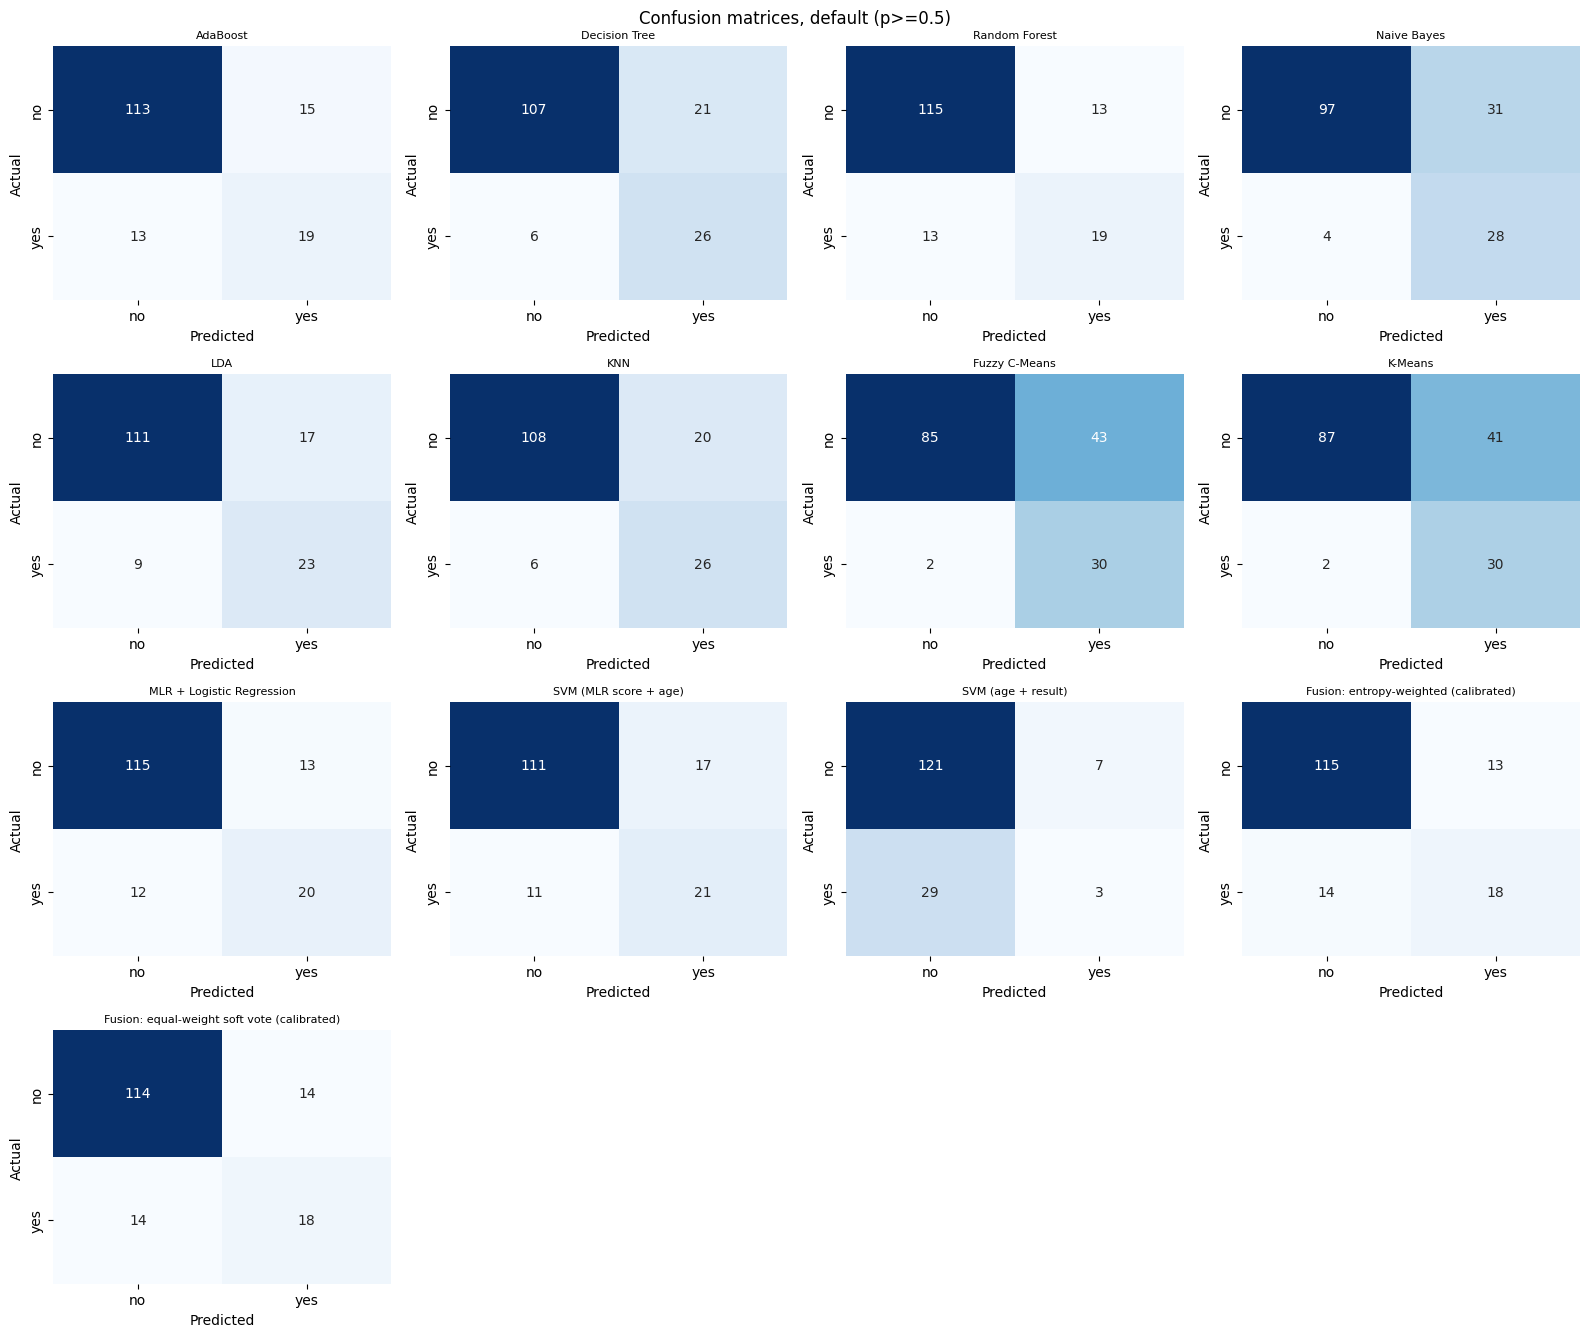

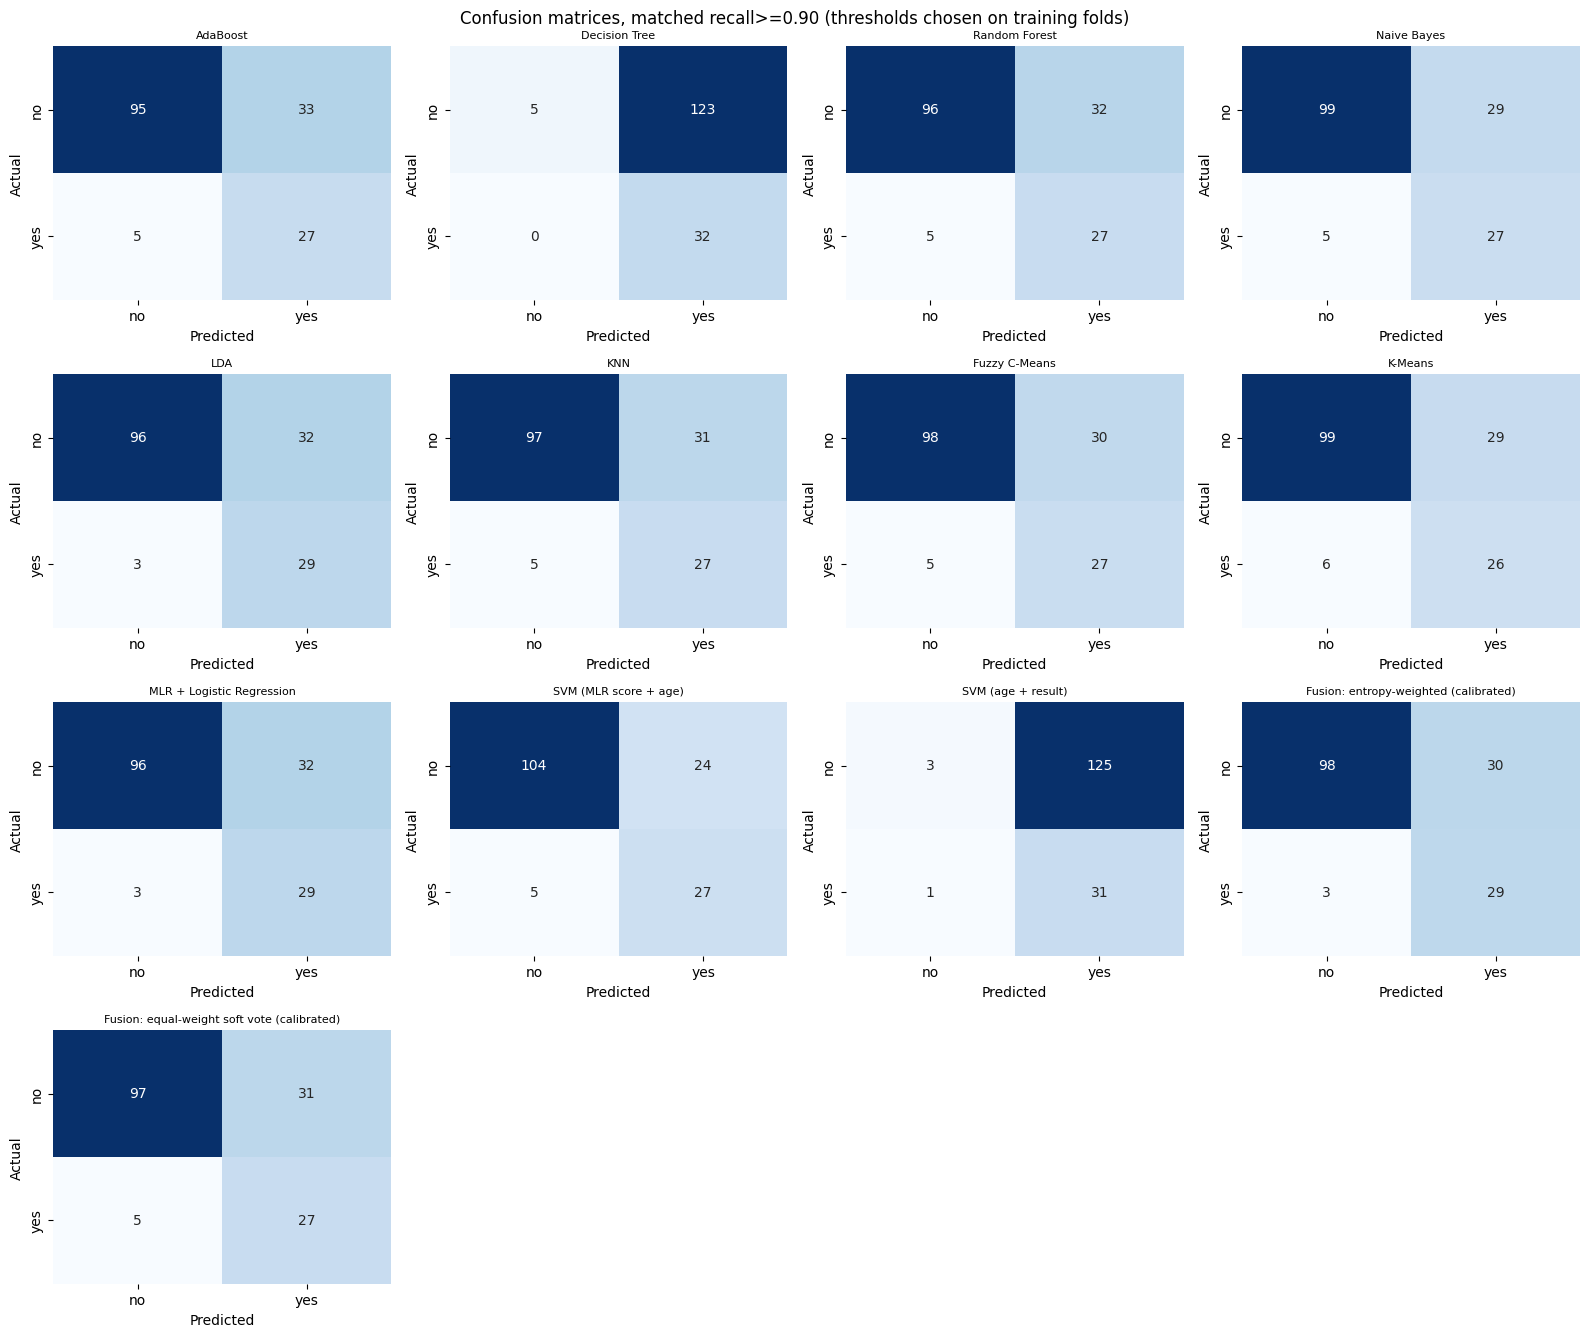

In [9]:
Xh = X if USE_RESULT else X.drop(columns=["result"], errors="ignore")
Xtr, Xte, ytr, yte = train_test_split(Xh, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"USE_RESULT={USE_RESULT} | train {Xtr.shape}, test {Xte.shape} | positives in test: {int(yte.sum())}")

res = evaluate_fold(Xtr, Xte, ytr, yte, USE_RESULT)
preds, preds_r, cal, fitted = res["preds"], res["preds_r"], res["cal"], res["fitted"]
print("Decision tree size chosen by the 1-SE rule:", res["leaves"], "leaves")

hold = pd.DataFrame(res["rows"])
for op in (OP_DEF, OP_REC):
    print(f"\n--- operating point: {op} ---")
    display(hold[hold["op"] == op].set_index("model")[COLS].round(3).sort_values("bal_acc", ascending=False))


def plot_cm_grid(pr, title):
    names = list(pr)
    ncol = 4
    nrow = int(np.ceil(len(names) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.4 * nrow))
    for ax, n in zip(axes.flat, names):
        sns.heatmap(confusion_matrix(yte, pr[n], labels=[0, 1]), annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["no", "yes"], yticklabels=["no", "yes"], ax=ax)
        ax.set_title(n, fontsize=8)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    for ax in list(axes.flat)[len(names):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_cm_grid(preds, f"Confusion matrices, {OP_DEF}")
plot_cm_grid(preds_r, f"Confusion matrices, {OP_REC} (thresholds chosen on training folds)")

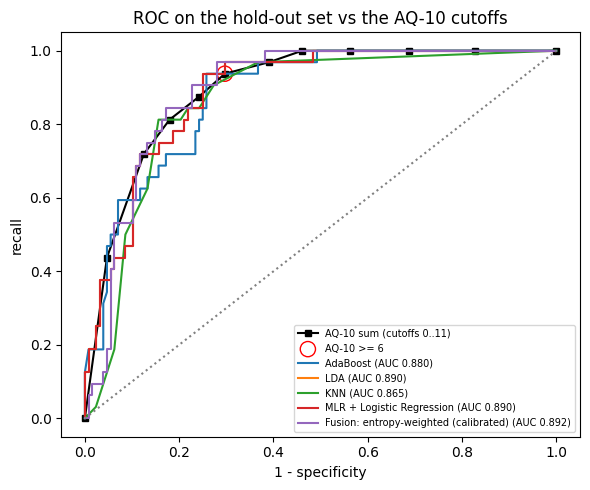

In [10]:
aq_te = Xte[AQ_COLUMNS].sum(axis=1).values
pts = []
for cutoff in range(0, 12):
    pr = (aq_te >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, pr, labels=[0, 1]).ravel()
    pts.append((fp / (fp + tn), tp / (tp + fn)))

plt.figure(figsize=(6, 5))
plt.plot(*zip(*pts), "ks-", ms=4, label="AQ-10 sum (cutoffs 0..11)")
plt.scatter([pts[6][0]], [pts[6][1]], s=120, facecolors="none", edgecolors="r", label="AQ-10 >= 6")
for n in ["AdaBoost", "LDA", "KNN", "MLR + Logistic Regression", "Fusion: entropy-weighted (calibrated)"]:
    fpr, tpr, _ = roc_curve(yte, cal[n])
    plt.plot(fpr, tpr, label=f"{n} (AUC {roc_auc_score(yte, cal[n]):.3f})")
plt.plot([0, 1], [0, 1], ":", c="gray")
plt.xlabel("1 - specificity")
plt.ylabel("recall")
plt.title("ROC on the hold-out set vs the AQ-10 cutoffs")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 8. Supplementary figures (hold-out split)

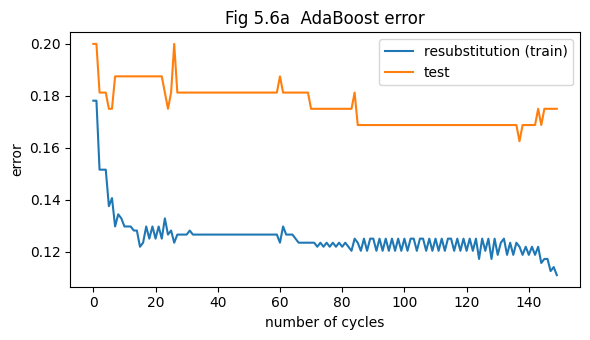

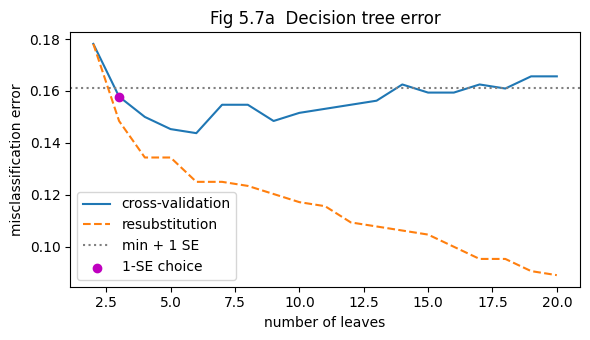

1-SE choice: 3 leaves (this is the size used by the Decision Tree model)


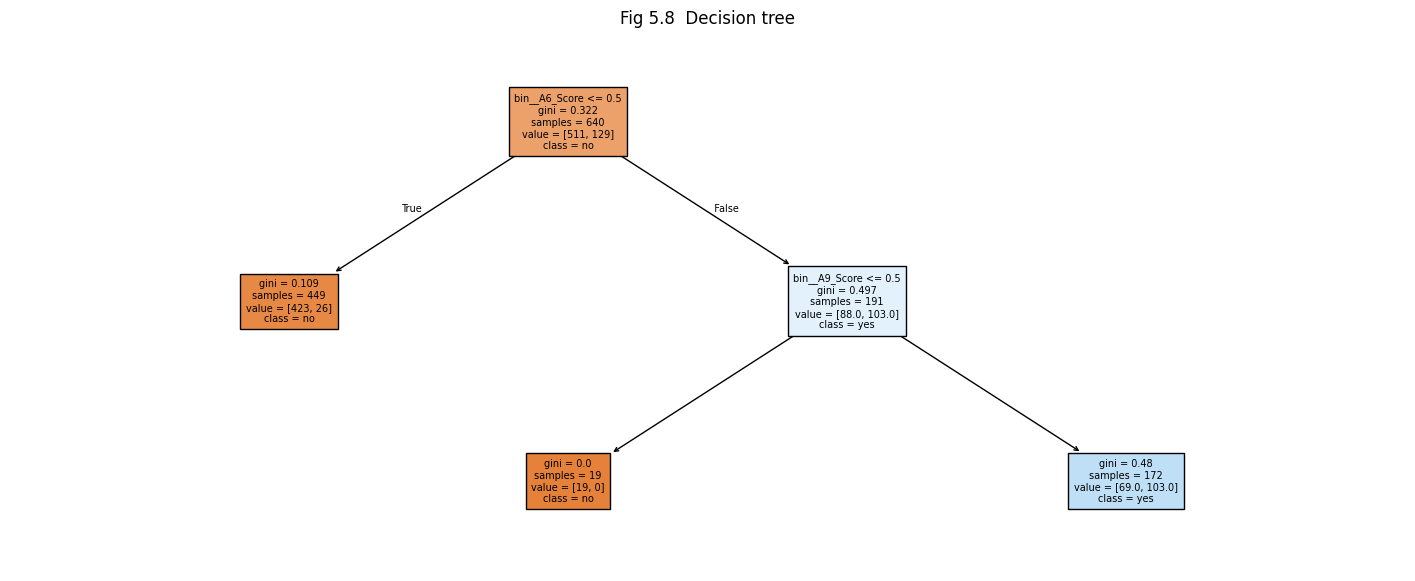

In [11]:
ada_pipe = fitted["AdaBoost"]
prep = ada_pipe.named_steps["prep"]
ada = ada_pipe.named_steps["clf"]
Ttr, Tte = prep.transform(Xtr), prep.transform(Xte)
tr_err = [1 - accuracy_score(ytr, p) for p in ada.staged_predict(Ttr)]
te_err = [1 - accuracy_score(yte, p) for p in ada.staged_predict(Tte)]

plt.figure(figsize=(6, 3.5))
plt.plot(tr_err, label="resubstitution (train)")
plt.plot(te_err, label="test")
plt.xlabel("number of cycles")
plt.ylabel("error")
plt.title("Fig 5.6a  AdaBoost error")
plt.legend()
plt.tight_layout()
plt.show()

tc = tree_curve(Xtr, ytr, USE_RESULT, with_resub=True)
plt.figure(figsize=(6, 3.5))
plt.plot(tc["leaves"], tc["cv_mean"], label="cross-validation")
plt.plot(tc["leaves"], tc["resub"], "--", label="resubstitution")
plt.axhline(tc["cv_mean"][tc["best"]] + tc["cv_se"][tc["best"]], ls=":", c="gray", label="min + 1 SE")
plt.scatter([tc["choice"]], [tc["cv_mean"][tc["one_se"]]], c="m", zorder=3, label="1-SE choice")
plt.xlabel("number of leaves")
plt.ylabel("misclassification error")
plt.title("Fig 5.7a  Decision tree error")
plt.legend()
plt.tight_layout()
plt.show()
print("1-SE choice:", tc["choice"], "leaves (this is the size used by the Decision Tree model)")

dt_pipe = fitted["Decision Tree"]
plt.figure(figsize=(18, 7))
plot_tree(dt_pipe.named_steps["clf"], feature_names=list(dt_pipe.named_steps["prep"].get_feature_names_out()),
          class_names=["no", "yes"], filled=True, fontsize=7)
plt.title("Fig 5.8  Decision tree")
plt.show()

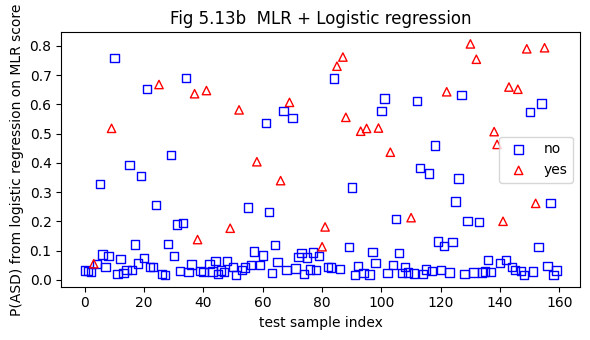

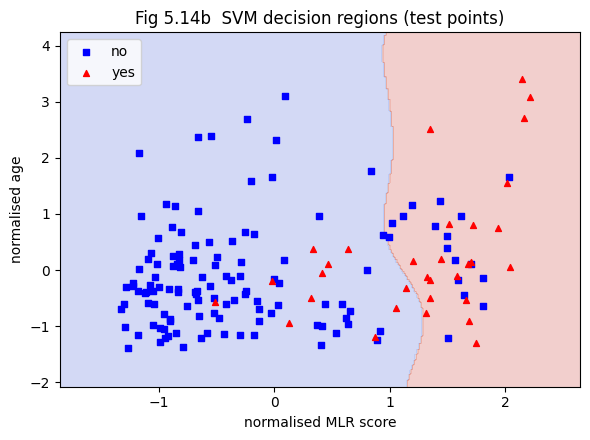

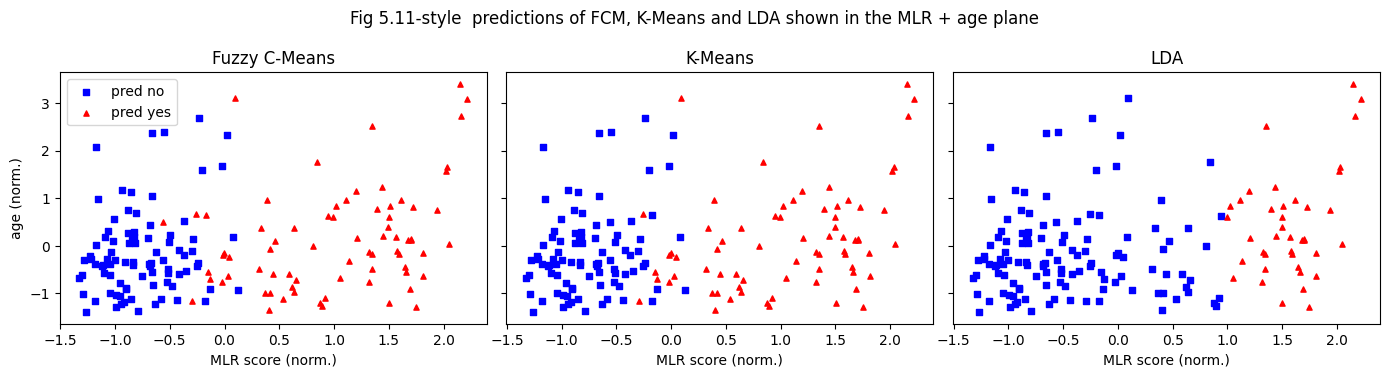

In [12]:
lr_pipe, svm_pipe = fitted["MLR + Logistic Regression"], fitted["SVM (MLR score + age)"]
p_lr = lr_pipe.predict_proba(Xte)[:, 1]
order = np.arange(len(yte))

plt.figure(figsize=(6, 3.5))
plt.scatter(order[yte.values == 0], p_lr[yte.values == 0], marker="s", facecolors="none", edgecolors="b", label="no")
plt.scatter(order[yte.values == 1], p_lr[yte.values == 1], marker="^", facecolors="none", edgecolors="r", label="yes")
plt.xlabel("test sample index")
plt.ylabel("P(ASD) from logistic regression on MLR score")
plt.title("Fig 5.13b  MLR + Logistic regression")
plt.legend()
plt.tight_layout()
plt.show()

Ztr, Zte = svm_pipe[:-1].transform(Xtr), svm_pipe[:-1].transform(Xte)
gx, gy = np.meshgrid(np.linspace(Ztr[:, 0].min() - .5, Ztr[:, 0].max() + .5, 300),
                     np.linspace(Ztr[:, 1].min() - .5, Ztr[:, 1].max() + .5, 300))
zz = svm_pipe.named_steps["clf"].predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)

plt.figure(figsize=(6, 4.5))
plt.contourf(gx, gy, zz, alpha=.25, cmap="coolwarm")
for cls, marker, color in [(0, "s", "b"), (1, "^", "r")]:
    plt.scatter(Zte[yte.values == cls, 0], Zte[yte.values == cls, 1],
                marker=marker, c=color, s=18, label=["no", "yes"][cls])
plt.xlabel("normalised MLR score")
plt.ylabel("normalised age")
plt.title("Fig 5.14b  SVM decision regions (test points)")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True)
for ax, n in zip(axes, ["Fuzzy C-Means", "K-Means", "LDA"]):
    pr = np.asarray(preds[n])
    ax.scatter(Zte[pr == 0, 0], Zte[pr == 0, 1], c="b", marker="s", s=14, label="pred no")
    ax.scatter(Zte[pr == 1, 0], Zte[pr == 1, 1], c="r", marker="^", s=14, label="pred yes")
    ax.set_title(n)
    ax.set_xlabel("MLR score (norm.)")
axes[0].set_ylabel("age (norm.)")
axes[0].legend()
fig.suptitle("Fig 5.11-style  predictions of FCM, K-Means and LDA shown in the MLR + age plane")
plt.tight_layout()
plt.show()

## 9. Repeated stratified cross-validation

Mean and standard deviation over folds, with and without `result`. For each setting the tables show:

1. results at the default threshold,
2. results at a matched recall, where specificity and precision are directly comparable,
3. paired per-fold differences against the AQ baseline (descriptive only, since CV folds overlap).

In [13]:
def cv_run(X_in, y_in, use_result):
    Xc = X_in if use_result else X_in.drop(columns=["result"], errors="ignore")
    rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    all_rows = []
    for fold, (tr, te) in enumerate(rskf.split(Xc, y_in)):
        out = evaluate_fold(Xc.iloc[tr], Xc.iloc[te], y_in.iloc[tr], y_in.iloc[te], use_result, fold)
        all_rows += out["rows"]
    return all_rows


cv_results = {}
for flag in ([True, False] if "result" in X else [False]):
    rows_cv = cv_run(X, y, flag)
    cv_results[flag] = rows_cv
    print(f"\n==================== USE_RESULT = {flag} ====================")
    for op in (OP_DEF, OP_REC):
        print(f"\n--- {op} ---")
        display(summarize(rows_cv, op)[0])
    print("\n--- paired ΔAUC vs AQ-10 sum (threshold-free) ---")
    display(paired(rows_cv, OP_DEF, "auc", "Baseline: AQ-10 >= 6"))
    print(f"--- paired Δspecificity vs AQ sum at matched recall >= {TARGET_RECALL:.2f} ---")
    display(paired(rows_cv, OP_REC, "spec", "Baseline: AQ sum (cutoff chosen on train)"))


==================== USE_RESULT = True ====================

--- default (p>=0.5) ---


,accuracy,bal_acc,precision,recall,spec,f1,auc
model,,,,,,,
Baseline: AQ-10 >= 6,77.375 ± 2.161,83.734 ± 1.915,0.47 ± 0.026,0.944 ± 0.032,0.731 ± 0.027,0.627 ± 0.026,0.911 ± 0.019
Naive Bayes,78.312 ± 4.41,83.395 ± 2.971,0.485 ± 0.055,0.919 ± 0.037,0.749 ± 0.056,0.633 ± 0.048,0.894 ± 0.029
K-Means,76.375 ± 2.665,82.995 ± 2.728,0.459 ± 0.029,0.941 ± 0.048,0.719 ± 0.033,0.616 ± 0.032,0.896 ± 0.021
Fuzzy C-Means,74.688 ± 2.83,82.524 ± 2.074,0.442 ± 0.027,0.956 ± 0.034,0.694 ± 0.037,0.604 ± 0.027,0.893 ± 0.019
KNN,84.312 ± 2.878,80.865 ± 3.082,0.592 ± 0.064,0.751 ± 0.056,0.866 ± 0.035,0.66 ± 0.049,0.886 ± 0.026
LDA,85.0 ± 2.99,80.022 ± 4.023,0.612 ± 0.07,0.717 ± 0.068,0.883 ± 0.029,0.659 ± 0.062,0.896 ± 0.032
Decision Tree,84.25 ± 2.444,79.104 ± 5.333,0.595 ± 0.055,0.705 ± 0.122,0.877 ± 0.034,0.64 ± 0.065,0.833 ± 0.039
SVM (MLR score + age),85.312 ± 2.736,78.602 ± 4.494,0.627 ± 0.068,0.674 ± 0.081,0.898 ± 0.023,0.648 ± 0.068,0.836 ± 0.033
AdaBoost,85.625 ± 1.768,78.226 ± 1.713,0.643 ± 0.056,0.658 ± 0.035,0.906 ± 0.024,0.649 ± 0.03,0.9 ± 0.024



--- matched recall>=0.90 ---


,accuracy,bal_acc,precision,recall,spec,f1,auc
model,,,,,,,
K-Means,81.75 ± 2.037,84.851 ± 2.611,0.529 ± 0.031,0.9 ± 0.064,0.797 ± 0.031,0.665 ± 0.028,0.896 ± 0.021
Fusion: entropy-weighted (calibrated),81.312 ± 3.958,84.812 ± 3.569,0.527 ± 0.059,0.907 ± 0.068,0.79 ± 0.052,0.664 ± 0.051,0.911 ± 0.024
Fuzzy C-Means,80.625 ± 1.768,84.151 ± 2.993,0.511 ± 0.024,0.901 ± 0.07,0.782 ± 0.026,0.651 ± 0.029,0.893 ± 0.019
Fusion: equal-weight soft vote (calibrated),81.0 ± 3.513,83.795 ± 3.553,0.522 ± 0.053,0.885 ± 0.077,0.791 ± 0.049,0.653 ± 0.046,0.907 ± 0.023
Random Forest,79.625 ± 3.162,83.645 ± 1.795,0.501 ± 0.044,0.904 ± 0.054,0.769 ± 0.049,0.642 ± 0.03,0.898 ± 0.025
AdaBoost,79.188 ± 2.466,83.474 ± 2.172,0.492 ± 0.032,0.907 ± 0.03,0.763 ± 0.03,0.638 ± 0.031,0.9 ± 0.024
KNN,79.0 ± 2.844,83.465 ± 2.718,0.492 ± 0.039,0.91 ± 0.073,0.76 ± 0.045,0.636 ± 0.032,0.886 ± 0.026
MLR + Logistic Regression,79.312 ± 2.659,83.102 ± 3.082,0.495 ± 0.039,0.894 ± 0.074,0.768 ± 0.04,0.635 ± 0.034,0.896 ± 0.032
Naive Bayes,78.75 ± 3.033,83.076 ± 2.093,0.489 ± 0.043,0.903 ± 0.063,0.758 ± 0.048,0.632 ± 0.03,0.894 ± 0.029



--- paired ΔAUC vs AQ-10 sum (threshold-free) ---


...

,accuracy,bal_acc,precision,recall,spec,f1,auc
model,,,,,,,
Fusion: entropy-weighted (calibrated),80.688 ± 3.166,84.299 ± 2.907,0.516 ± 0.045,0.904 ± 0.065,0.782 ± 0.045,0.654 ± 0.038,0.912 ± 0.026
Fusion: equal-weight soft vote (calibrated),81.0 ± 2.934,84.254 ± 3.009,0.52 ± 0.042,0.897 ± 0.072,0.788 ± 0.044,0.656 ± 0.037,0.908 ± 0.024
KNN,78.5 ± 2.655,83.505 ± 2.607,0.484 ± 0.033,0.919 ± 0.065,0.751 ± 0.04,0.633 ± 0.031,0.89 ± 0.03
Fuzzy C-Means,80.062 ± 2.863,83.432 ± 3.069,0.506 ± 0.04,0.891 ± 0.071,0.778 ± 0.042,0.643 ± 0.037,0.897 ± 0.022
K-Means,80.062 ± 2.787,83.199 ± 3.739,0.505 ± 0.039,0.885 ± 0.082,0.779 ± 0.038,0.641 ± 0.042,0.901 ± 0.021
AdaBoost,78.562 ± 1.475,83.198 ± 1.796,0.483 ± 0.019,0.91 ± 0.038,0.754 ± 0.019,0.631 ± 0.021,0.897 ± 0.025
Naive Bayes,78.188 ± 3.207,82.958 ± 2.191,0.482 ± 0.04,0.91 ± 0.05,0.75 ± 0.046,0.628 ± 0.033,0.891 ± 0.029
MLR + Logistic Regression,78.875 ± 2.987,82.941 ± 3.172,0.49 ± 0.042,0.897 ± 0.075,0.761 ± 0.044,0.632 ± 0.037,0.895 ± 0.032
Baseline: AQ sum (cutoff chosen on train),77.688 ± 2.413,82.757 ± 3.223,0.474 ± 0.03,0.913 ± 0.083,0.743 ± 0.039,0.622 ± 0.032,0.911 ± 0.019



--- paired ΔAUC vs AQ-10 sum (threshold-free) ---


,mean Δauc,std,folds better
model,,,
Fusion: entropy-weighted (calibrated),0.001,0.014,6
Fusion: equal-weight soft vote (calibrated),-0.002,0.013,4
K-Means,-0.009,0.008,1
AdaBoost,-0.013,0.014,2
Fuzzy C-Means,-0.014,0.008,0
Random Forest,-0.016,0.014,1
LDA,-0.016,0.020,2
MLR + Logistic Regression,-0.016,0.020,2
Naive Bayes,-0.020,0.017,2


--- paired Δspecificity vs AQ sum at matched recall >= 0.90 ---


,mean Δspec,std,folds better
model,,,
Fusion: equal-weight soft vote (calibrated),0.045,0.025,10
Fusion: entropy-weighted (calibrated),0.040,0.032,7
K-Means,0.037,0.016,10
Fuzzy C-Means,0.035,0.021,10
MLR + Logistic Regression,0.019,0.026,7
AdaBoost,0.012,0.028,8
KNN,0.009,0.021,7
LDA,0.007,0.034,6
Naive Bayes,0.007,0.034,5


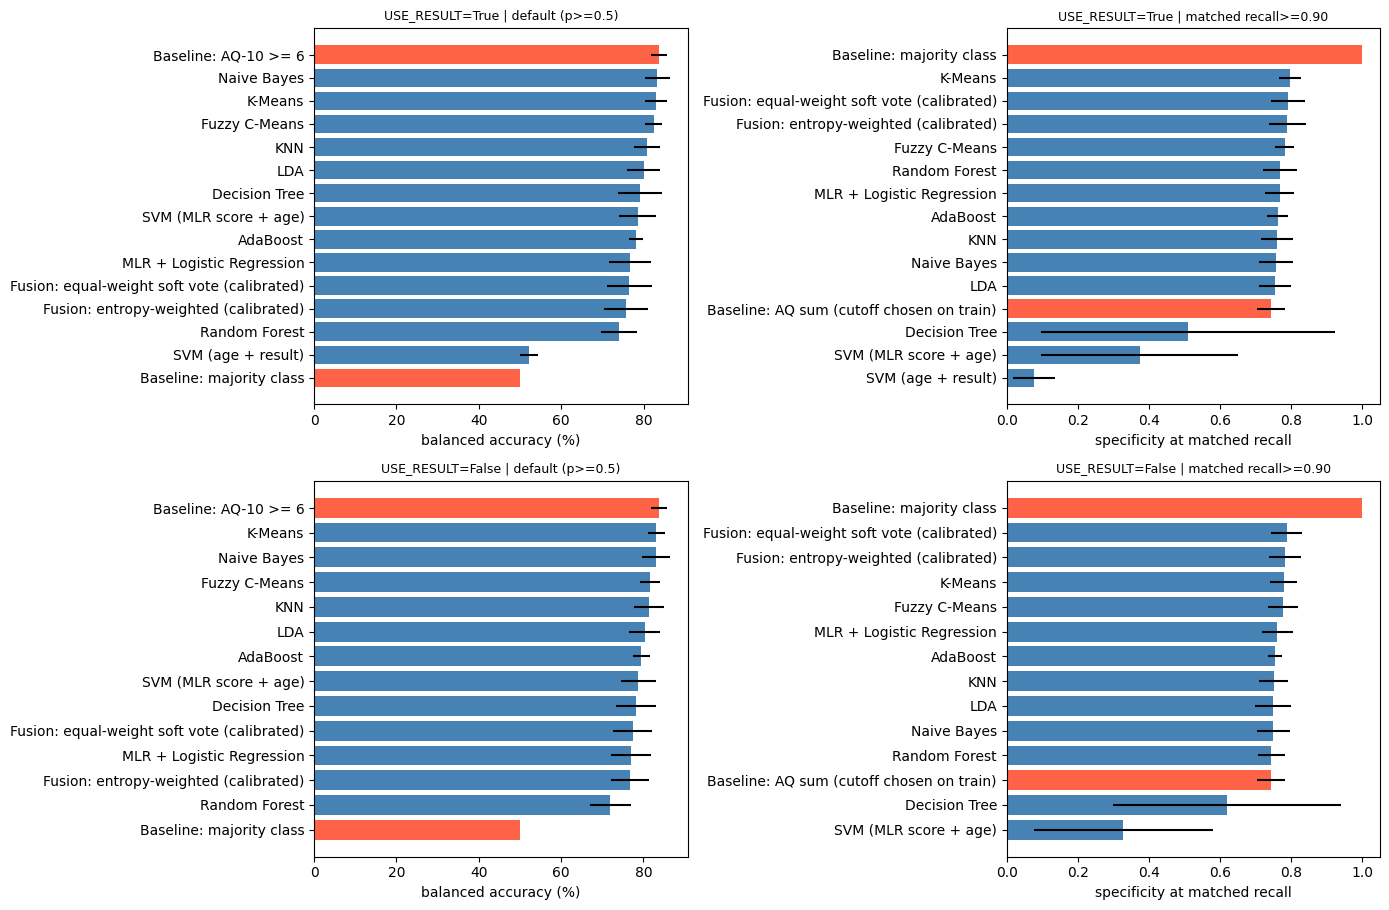

In [14]:
panels = [(OP_DEF, "bal_acc", "balanced accuracy (%)"),
          (OP_REC, "spec", "specificity at matched recall")]
fig, axes = plt.subplots(len(cv_results), 2, figsize=(14, 4.6 * len(cv_results)), squeeze=False)
for row, (flag, rows_cv) in zip(axes, cv_results.items()):
    for ax, (op, metric, xlabel) in zip(row, panels):
        _, mean, std = summarize(rows_cv, op)
        values = mean[metric].sort_values()
        err = std[metric].loc[values.index]
        colors = ["tomato" if n.startswith("Baseline") else "steelblue" for n in values.index]
        ax.barh(values.index, values.values, xerr=err.values, color=colors)
        ax.set_xlabel(xlabel)
        ax.set_title(f"USE_RESULT={flag} | {op}", fontsize=9)
plt.tight_layout()
plt.show()

## Notes

- The AQ-10 rule is the reference to beat: a model adds value only if, at equal recall, it has higher specificity and precision than the AQ sum and a positive paired ΔAUC in most folds.
- Accuracy at the default threshold mostly reflects where the threshold sits; compare models by AUC and at matched recall.
- Differences smaller than about one standard deviation are within noise.
- Models with few distinct scores (shallow trees, KNN with small k, an RBF SVM on a two-dimensional plane) cannot be tuned smoothly to a recall target, so their matched-recall rows vary strongly between folds.
- If results with and without `result` are nearly identical, `result` adds little beyond the AQ items (see the diagnostic in section 3).